## PART - B Practical (Python Programming)

## Employee Performance 

### Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

### Loading Dataset

In [2]:
df = pd.read_csv("employee_performance_200.csv")
df

,Employee_ID,Department,Age,Salary,Projects_Completed,Working_Hours,Performance_Score,Promotion_Status
0,EMP1000,IT,50,108879,15,43,75,Yes
1,EMP1001,Operations,36,96295,9,60,75,No
2,EMP1002,Operations,29,113614,12,55,80,Yes
3,EMP1003,Marketing,42,36111,5,34,49,No
4,EMP1004,HR,40,62504,1,32,48,No
...,...,...,...,...,...,...,...,...
195,EMP1195,Finance,40,115852,13,30,54,No
196,EMP1196,Operations,41,57217,5,31,56,No
197,EMP1197,Marketing,53,33308,10,38,64,No
198,EMP1198,Marketing,28,30949,10,32,53,No


## Step 1 - Central Tendency and Dispersion

### Mean, Median and Mode of Salary

In [3]:
mean_salary = df["Salary"].mean()
median_salary = df["Salary"].median()
mode_salary = df["Salary"].mode()[0]

print("Mean Salary :", mean_salary)
print("Median Salary :", median_salary)
print("Mode Salary :", mode_salary)

Mean Salary : 72067.145
Median Salary : 72843.5
Mode Salary : 25301


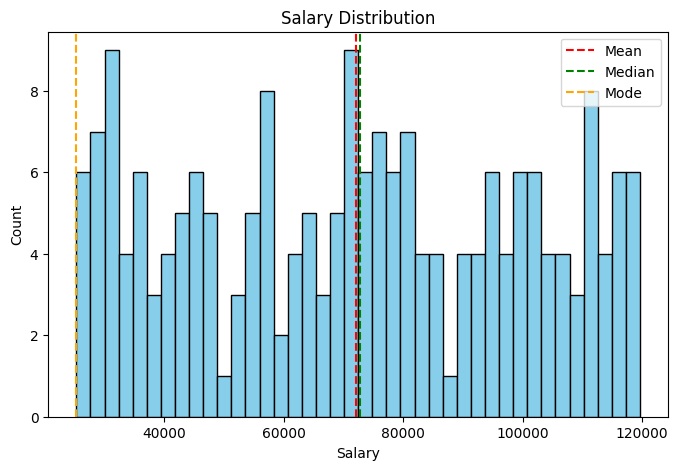

In [4]:
plt.figure(figsize=(8,5))
plt.hist(df["Salary"], bins=40, color="skyblue", edgecolor="black")

plt.axvline(mean_salary, color="red", linestyle="--", label="Mean")
plt.axvline(median_salary, color="green", linestyle="--", label="Median")
plt.axvline(mode_salary, color="orange", linestyle="--", label="Mode")

plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Count")
plt.legend()
plt.show()

### Variance and Standard Deviation of Projects Completed

In [7]:
variance_projects = df["Projects_Completed"].var()
std_projects = df["Projects_Completed"].std()

print("Variance of Projects Completed :", variance_projects)
print("Standard Deviation of Projects Completed :", std_projects)

Variance of Projects Completed : 18.690552763819095
Standard Deviation of Projects Completed : 4.3232571938087485


## Step 2 - Probability and Events

### Probability of Employees Getting Promoted

In [8]:
total = len(df)
promoted = len(df[df["Promotion_Status"] == "Yes"])
not_promoted = len(df[df["Promotion_Status"] == "No"])

p_promoted = promoted / total
p_not_promoted = not_promoted / total

print("Total Employees :", total)
print("Promoted :", promoted)
print("Not Promoted :", not_promoted)
print("P(Promotion) :", p_promoted)
print("P(No Promotion) :", p_not_promoted)

Total Employees : 200
Promoted : 52
Not Promoted : 148
P(Promotion) : 0.26
P(No Promotion) : 0.74


### Pie Chart

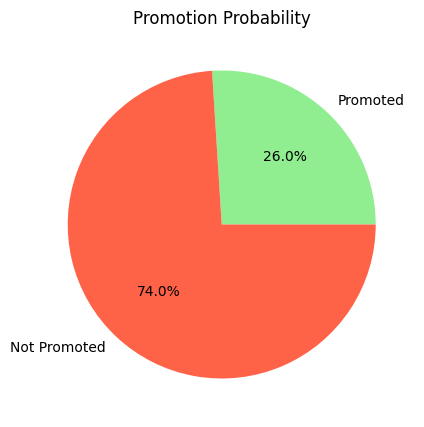

In [9]:
plt.figure(figsize=(5, 5))
plt.pie([promoted, not_promoted], labels=["Promoted", "Not Promoted"],
        autopct="%1.1f%%", colors=["lightgreen", "tomato"])
plt.title("Promotion Probability")
plt.show()

### Contingency Table

In [10]:
ct = pd.crosstab(
    df["Department"],
    df["Promotion_Status"]
)

print(ct)

Promotion_Status  No  Yes
Department               
Finance           20   13
HR                31    7
IT                27    9
Marketing         29    7
Operations        23    8
Sales             18    8


### Conditional Probability

In [11]:
high_perf = df[df["Performance_Score"] > 80]

p_promo_high = (
    len(high_perf[high_perf["Promotion_Status"] == "Yes"])
    /
    len(high_perf)
)

print("Employees with Performance Score > 80 :", len(high_perf))
print("Promoted among them :", len(high_perf[high_perf["Promotion_Status"] == "Yes"]))
print("P(Promotion | Performance Score > 80) :", p_promo_high)

Employees with Performance Score > 80 : 20
Promoted among them : 20
P(Promotion | Performance Score > 80) : 1.0


## Step 3 - Distributions and Visualization

### Histogram of Performance Score with Gaussian Curve

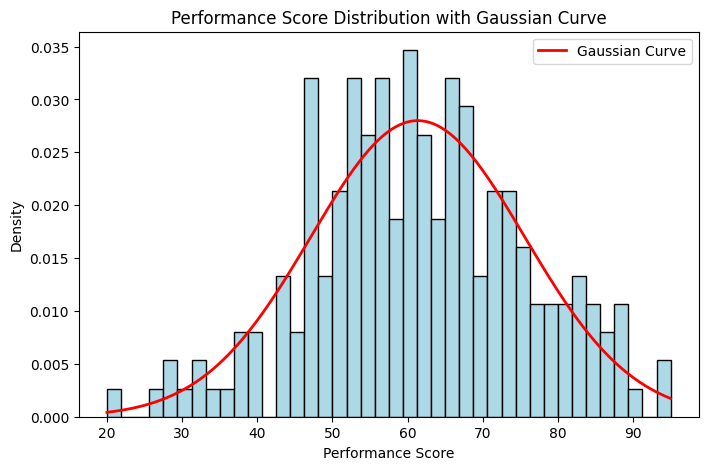

In [12]:
mu = df["Performance_Score"].mean()
sigma = df["Performance_Score"].std()

plt.figure(figsize=(8, 5))
plt.hist(df["Performance_Score"], bins=40, density=True, color="lightblue", edgecolor="black")

x = np.linspace(df["Performance_Score"].min(), df["Performance_Score"].max(), 200)
y = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)
plt.plot(x, y, color="red", linewidth=2, label="Gaussian Curve")

plt.title("Performance Score Distribution with Gaussian Curve")
plt.xlabel("Performance Score")
plt.ylabel("Density")
plt.legend()
plt.show()

### Skewness and Kurtosis of Salary

In [13]:
skewness = df["Salary"].skew()
kurt = df["Salary"].kurt()

print("Skewness of Salary :", skewness)
print("Kurtosis of Salary :", kurt)

Skewness of Salary : -0.010941274992422173
Kurtosis of Salary : -1.2011558783836063


### Q-Q Plot of Projects Completed

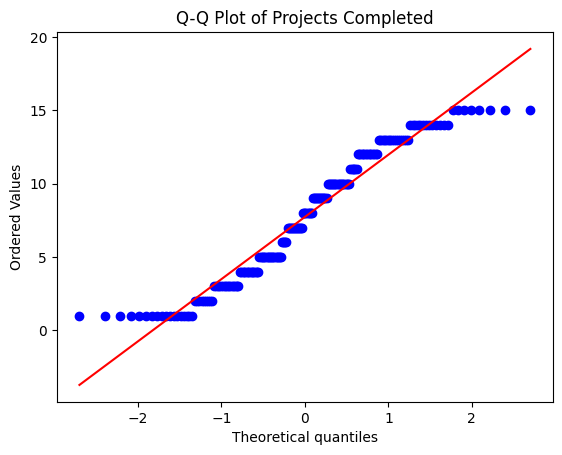

In [14]:
stats.probplot(df["Projects_Completed"], dist="norm", plot=plt)
plt.title("Q-Q Plot of Projects Completed")
plt.show()

## Step 4 - Linear Algebra Application

### Taking first 5 employees Projects Completed and Working Hours as vectors

In [15]:
v1 = np.array(df[["Projects_Completed", "Working_Hours"]].iloc[0])
v2 = np.array(df[["Projects_Completed", "Working_Hours"]].iloc[1])

print("Vector 1 (Employee 1) :", v1)
print("Vector 2 (Employee 2) :", v2)

Vector 1 (Employee 1) : [15 43]
Vector 2 (Employee 2) : [ 9 60]


### Dot Product between two employee vectors

In [16]:
dot = np.dot(v1, v2)
print("Dot Product of v1 and v2 :", dot)

Dot Product of v1 and v2 : 2715


### Norm 1 and Norm 2 of an employee work vector

In [17]:
norm1_v1 = np.linalg.norm(v1, ord=1)
norm2_v1 = np.linalg.norm(v1, ord=2)

print("Norm 1 of Employee 1 vector :", norm1_v1)
print("Norm 2 of Employee 1 vector :", norm2_v1)

Norm 1 of Employee 1 vector : 58.0
Norm 2 of Employee 1 vector : 45.5411901469428


### Angle between two employee work vectors

In [18]:
cos_angle = dot / (np.linalg.norm(v1) * np.linalg.norm(v2))
angle = np.degrees(np.arccos(cos_angle))
print("Angle between v1 and v2 :", angle, "degrees")

Angle between v1 and v2 : 10.699906765713143 degrees
